<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/DARPA_Program_Ecosystem_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DARPA Program Ecosystem Network

**Goal:** Map relationships among DARPA programs, universities, contractors, and technologies to discover hidden innovation hubs using bipartite graphs and ecosystem analysis.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')
print('Project environment initialized.')

Project environment initialized.


## Data Loading and Initial Exploration

In this section, we will load the DARPA archives, university research project data, and contractor information.

In [2]:
import random

# Seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define entities
programs = [f'Program_{chr(65+i)}' for i in range(8)]
universities = ['MIT', 'Stanford', 'CMU', 'UC Berkeley', 'Caltech', 'Georgia Tech', 'UT Austin']
contractors = ['Lockheed Martin', 'Raytheon', 'Northrop Grumman', 'Boeing', 'General Dynamics', 'Leidos']
technologies = ['AI', 'Quantum Computing', 'Hypersonics', 'Cybersecurity', 'Directed Energy', 'Microchips']

# Generate synthetic relationship data
data = []
for p in programs:
    # Assign random universities to each program
    for u in random.sample(universities, k=random.randint(1, 3)):
        data.append({'Program': p, 'Entity': u, 'Type': 'University', 'Tech': random.choice(technologies)})
    # Assign random contractors to each program
    for c in random.sample(contractors, k=random.randint(1, 2)):
        data.append({'Program': p, 'Entity': c, 'Type': 'Contractor', 'Tech': random.choice(technologies)})

df = pd.DataFrame(data)
print('Synthetic DARPA Ecosystem Data Created:')
display(df.head())

# Build the Graph
G = nx.Graph()
for _, row in df.iterrows():
    G.add_node(row['Program'], node_type='Program')
    G.add_node(row['Entity'], node_type=row['Type'])
    G.add_edge(row['Program'], row['Entity'], technology=row['Tech'])

print(f'Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.')

Synthetic DARPA Ecosystem Data Created:


,Program,Entity,Type,Tech
0,Program_A,MIT,University,Quantum Computing
1,Program_A,UT Austin,University,Quantum Computing
2,Program_A,CMU,University,Quantum Computing
3,Program_A,Leidos,Contractor,Microchips
4,Program_B,MIT,University,AI


Graph constructed with 20 nodes and 31 edges.


## Network Visualization

Now, let's visualize the bipartite relationship between DARPA programs and their partners (Universities/Contractors).

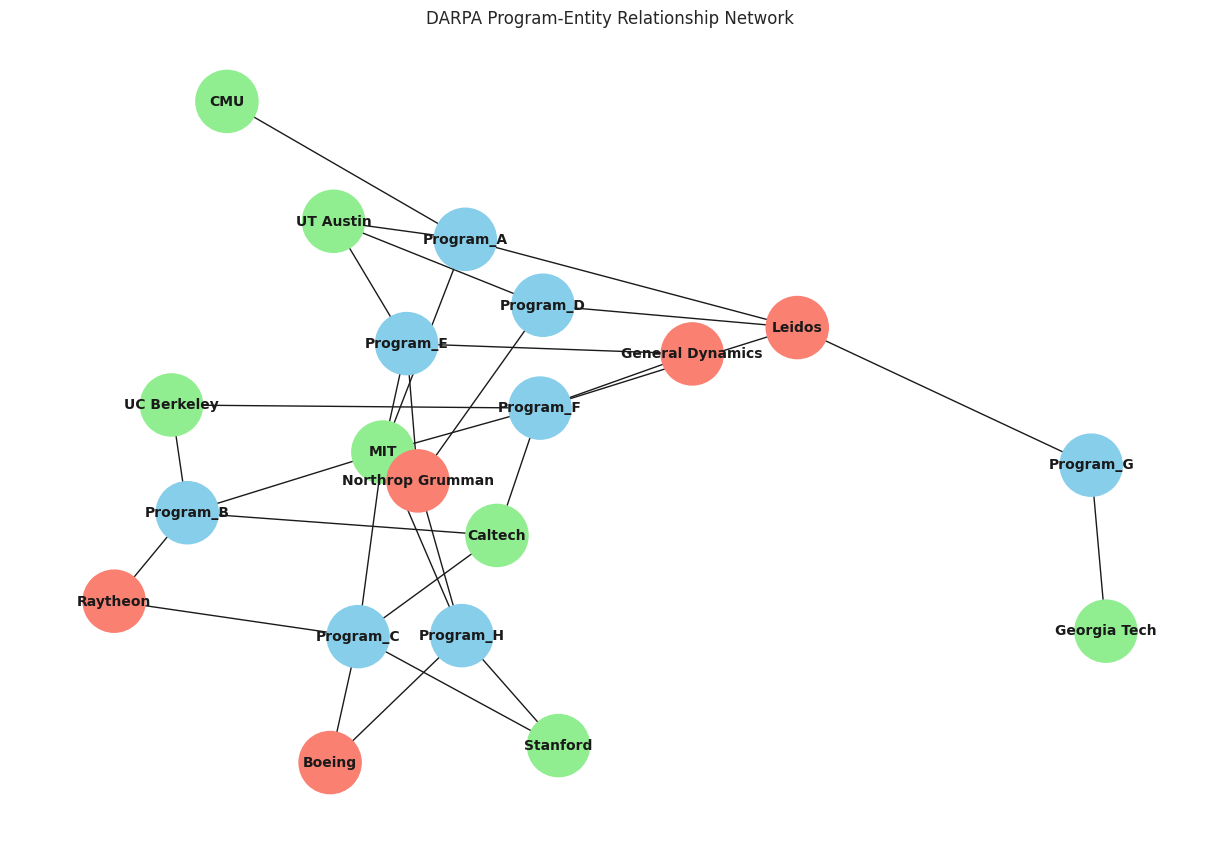

In [3]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Map colors by node type
color_map = []
for node in G:
    ntype = G.nodes[node]['node_type']
    if ntype == 'Program': color_map.append('skyblue')
    elif ntype == 'University': color_map.append('lightgreen')
    else: color_map.append('salmon')

nx.draw(G, pos, with_labels=True, node_color=color_map, node_size=2000, font_size=10, font_weight='bold')
plt.title('DARPA Program-Entity Relationship Network')
plt.show()

## Identifying Innovation Hubs

We will use Degree Centrality and Betweenness Centrality to identify the most influential entities in the ecosystem. Then, we will project the graph onto the 'Entity' set to see how universities and contractors are implicitly connected through shared DARPA programs.

Top Innovation Hubs (Degree Centrality):
MIT                 0.315789
Leidos              0.210526
UT Austin           0.157895
Caltech             0.157895
Northrop Grumman    0.157895
dtype: float64


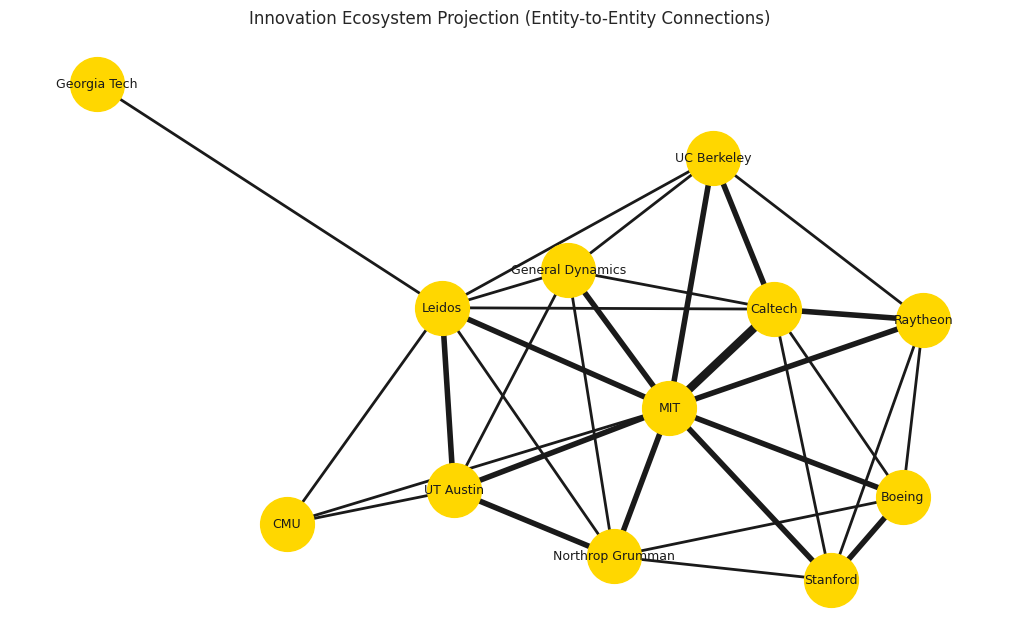

In [4]:
# Calculate Centrality
centrality = nx.degree_centrality(G)
# Filter for Entities (not Programs) to find hubs
entity_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] != 'Program']
hub_data = {node: centrality[node] for node in entity_nodes}

hub_series = pd.Series(hub_data).sort_values(ascending=False)
print("Top Innovation Hubs (Degree Centrality):")
print(hub_series.head())

# Project Bipartite Graph onto Entities
# Entities are connected if they share a common program
from networkx.algorithms import bipartite

# Get program nodes for the bipartite projection logic
program_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'Program']
entity_projection = bipartite.weighted_projected_graph(G, entity_nodes)

plt.figure(figsize=(10, 6))
pos_proj = nx.spring_layout(entity_projection, seed=42)
weights = [entity_projection[u][v]['weight'] * 2 for u, v in entity_projection.edges()]

nx.draw(entity_projection, pos_proj, with_labels=True,
        node_color='gold', node_size=1500,
        width=weights, font_size=9)
plt.title('Innovation Ecosystem Projection (Entity-to-Entity Connections)')
plt.show()